# King County House Price ANN

## Goal
Build a house-price regression notebook around the King County sales dataset and keep the original ANN idea from `housepre.ipynb`, but with cleaner preprocessing, repo-local paths, and a leakage-safe train/test workflow.

## Data
The notebook uses `data/kc_house_data.csv`, which contains residential sale records from King County with structural features, location, and sale timing.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

repo_root = Path.cwd()
data_path = repo_root / 'data' / 'kc_house_data.csv'
if not data_path.exists():
    alt_path = repo_root.parent / 'data' / 'kc_house_data.csv'
    if alt_path.exists():
        data_path = alt_path

raw_df = pd.read_csv(data_path)
raw_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [2]:
raw_df.shape, raw_df['price'].describe().round(2)

((21597, 21),
 count      21597.00
 mean      540296.57
 std       367368.14
 min        78000.00
 25%       322000.00
 50%       450000.00
 75%       645000.00
 max      7700000.00
 Name: price, dtype: float64)

## Preprocessing
I keep the dataset close to the original version, but make a few practical changes before modeling:

- drop `id` because it is just an identifier
- convert `date` into sale month and sale year
- add house age and renovation recency features
- keep `zipcode` as a categorical location signal instead of treating it like a numeric rank
- split before fitting any scaler or encoder

In [3]:
df = raw_df.copy()
df['date'] = pd.to_datetime(df['date'])
df['sale_year'] = df['date'].dt.year
df['sale_month'] = df['date'].dt.month
df['house_age_at_sale'] = df['sale_year'] - df['yr_built']
df['renovated'] = (df['yr_renovated'] > 0).astype(int)
df['years_since_renovation'] = np.where(
    df['renovated'] == 1,
    df['sale_year'] - df['yr_renovated'],
    0,
)
df['zipcode'] = df['zipcode'].astype(str)

model_df = df.drop(columns=['id', 'date'])
numeric_cols = [col for col in model_df.columns if col not in ['price', 'zipcode']]
categorical_cols = ['zipcode']

model_df[['price', 'sqft_living', 'grade', 'zipcode', 'sale_year', 'sale_month']].head()

,price,sqft_living,grade,zipcode,sale_year,sale_month
0,221900.0,1180,7,98178,2014,10
1,538000.0,2570,7,98125,2014,12
2,180000.0,770,6,98028,2015,2
3,604000.0,1960,7,98136,2014,12
4,510000.0,1680,8,98074,2015,2


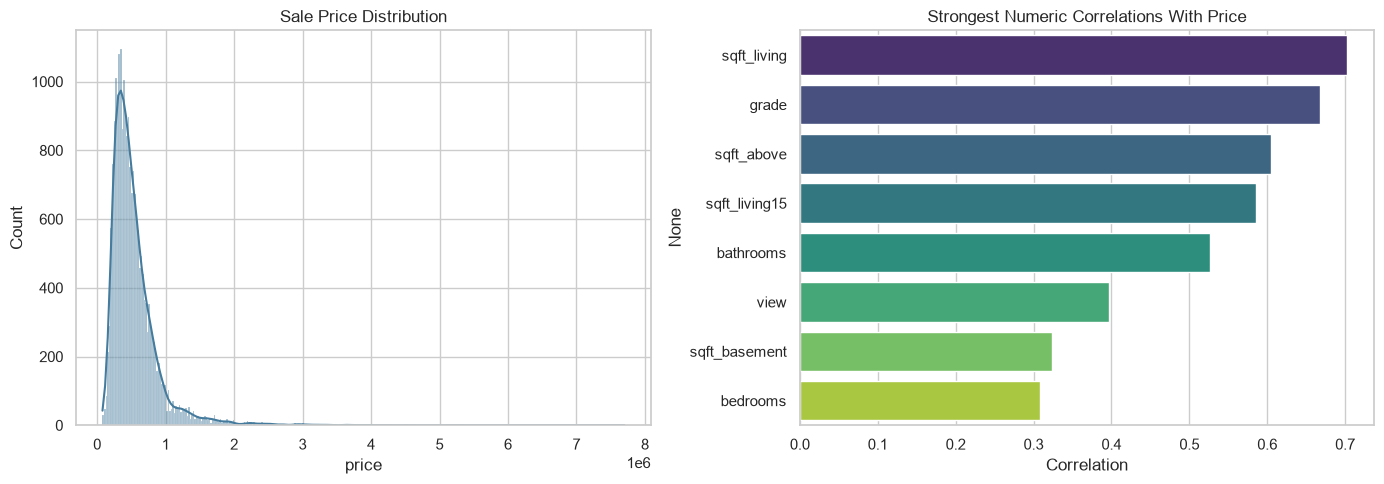

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(model_df['price'], kde=True, ax=axes[0], color='#457b9d')
axes[0].set_title('Sale Price Distribution')

corr = model_df.corr(numeric_only=True)['price'].drop('price').sort_values(key=np.abs, ascending=False).head(8)
sns.barplot(x=corr.values, y=corr.index, ax=axes[1], hue=corr.index, palette='viridis', legend=False)
axes[1].set_title('Strongest Numeric Correlations With Price')
axes[1].set_xlabel('Correlation')
plt.tight_layout()

## Model
The main model is a fully connected neural network regressor trained on `log1p(price)`. I standardize that transformed target before training so the ANN stays numerically stable, then convert predictions back to the original price scale.

For context, I compare it against a median baseline and a linear regression model fit on the same processed features.

In [5]:
X = model_df.drop(columns='price')
y = model_df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

y_train_log = np.log1p(y_train).to_numpy().reshape(-1, 1)

target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train_log).ravel()

try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('zip', encoder, categorical_cols),
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

X_train_proc.shape, X_test_proc.shape

((17277, 92), (4320, 92))

In [6]:
def evaluate_regression(y_true, pred):
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, pred))),
        'MAE': float(mean_absolute_error(y_true, pred)),
        'R2': float(r2_score(y_true, pred)),
    }

models = {
    'Median baseline': DummyRegressor(strategy='median'),
    'Linear regression': LinearRegression(),
    'ANN regressor': MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        alpha=5e-4,
        batch_size=256,
        learning_rate_init=0.001,
        max_iter=180,
        early_stopping=True,
        validation_fraction=0.12,
        n_iter_no_change=12,
        random_state=42,
    ),
}

fitted = {}
rows = []
for name, model in models.items():
    if name == 'ANN regressor':
        model.fit(X_train_proc, y_train_scaled)
        pred_scaled = model.predict(X_test_proc).reshape(-1, 1)
        pred_log = target_scaler.inverse_transform(pred_scaled).ravel()
    else:
        model.fit(X_train_proc, np.log1p(y_train))
        pred_log = model.predict(X_test_proc)

    pred = np.maximum(np.expm1(pred_log), 0)
    fitted[name] = model
    row = {'Model': name}
    row.update(evaluate_regression(y_test, pred))
    rows.append(row)

metrics_df = pd.DataFrame(rows).set_index('Model').sort_values('RMSE')
metrics_df.round(2)

,RMSE,MAE,R2
Model,,,
ANN regressor,117529.84,66968.70,0.89
Linear regression,153343.23,74395.25,0.82
Median baseline,370824.42,218689.96,-0.06


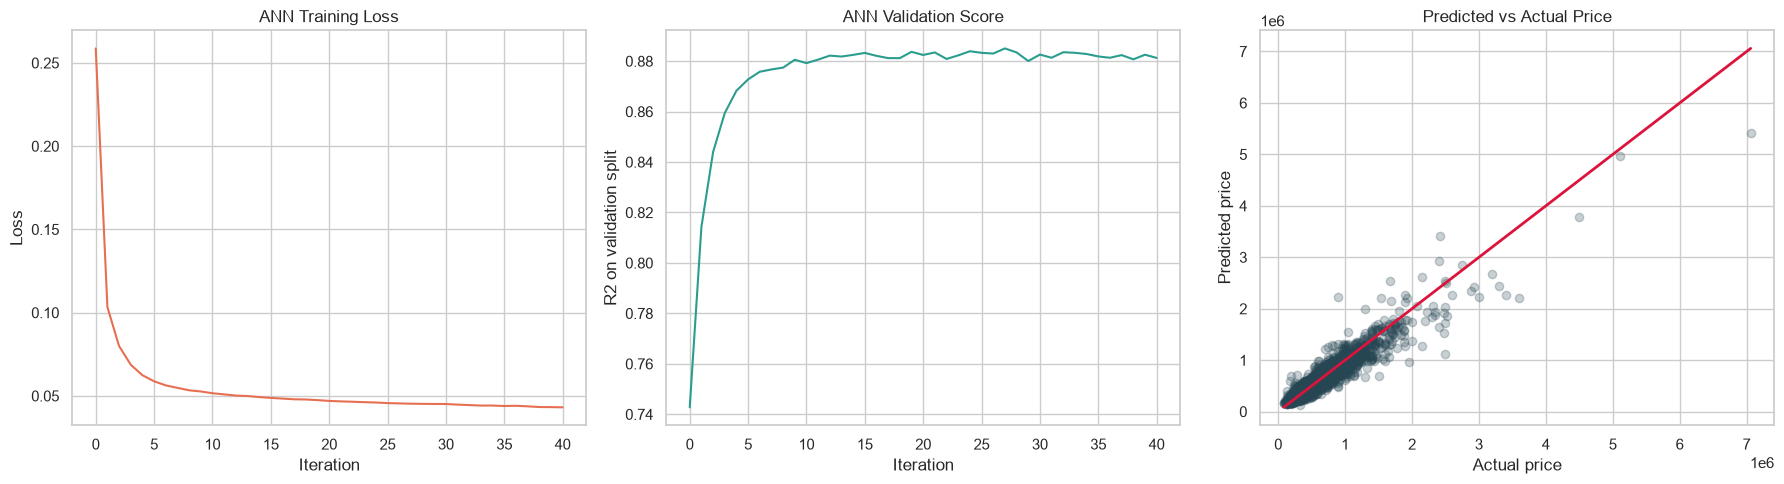

In [7]:
ann_model = fitted['ANN regressor']
ann_scaled_pred = ann_model.predict(X_test_proc).reshape(-1, 1)
ann_pred = np.maximum(np.expm1(target_scaler.inverse_transform(ann_scaled_pred).ravel()), 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(ann_model.loss_curve_, color='#e76f51')
axes[0].set_title('ANN Training Loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')

if getattr(ann_model, 'validation_scores_', None):
    axes[1].plot(ann_model.validation_scores_, color='#2a9d8f')
    axes[1].set_title('ANN Validation Score')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('R2 on validation split')
else:
    axes[1].axis('off')

axes[2].scatter(y_test, ann_pred, alpha=0.25, color='#264653')
line_start = min(y_test.min(), ann_pred.min())
line_end = max(y_test.max(), ann_pred.max())
axes[2].plot([line_start, line_end], [line_start, line_end], color='crimson', linewidth=2)
axes[2].set_title('Predicted vs Actual Price')
axes[2].set_xlabel('Actual price')
axes[2].set_ylabel('Predicted price')

plt.tight_layout()

,3686
bedrooms,3
bathrooms,0.75
sqft_living,850
sqft_lot,8573
floors,1.0
waterfront,0
view,0
condition,3
grade,6
sqft_above,600


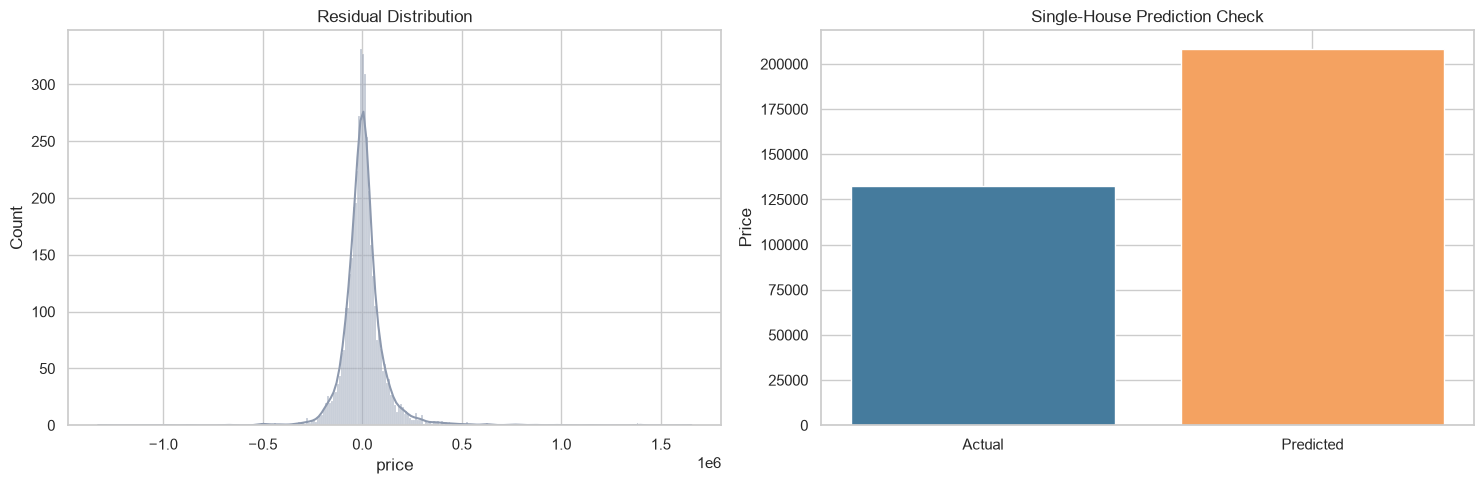

In [8]:
residuals = y_test - ann_pred
comparison = pd.DataFrame({
    'actual_price': y_test.values,
    'predicted_price': ann_pred,
    'absolute_error': np.abs(residuals),
}).sort_values('absolute_error', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(residuals, kde=True, ax=axes[0], color='#8d99ae')
axes[0].set_title('Residual Distribution')

sample_house = X_test.iloc[[0]].copy()
sample_prediction = float(ann_pred[0])
sample_summary = sample_house.assign(
    actual_price=float(y_test.iloc[0]),
    predicted_price=sample_prediction,
)

axes[1].bar(['Actual', 'Predicted'], [y_test.iloc[0], sample_prediction], color=['#457b9d', '#f4a261'])
axes[1].set_title('Single-House Prediction Check')
axes[1].set_ylabel('Price')
plt.tight_layout()

sample_summary.round(2).T

## Result
The ANN is evaluated on a held-out test split after all scaling and encoding are fit on the training data only. The goal here is not leaderboard chasing; it is a cleaner, reproducible version of the original house-price notebook.

## What I Learned
Living area, grade, and location still do most of the work. The ANN becomes much more usable once the target is stabilized with `log1p` and the zipcode signal is encoded explicitly instead of being treated like a numeric rank.

## Limits
This is still a tabular housing model on one county and one time window. It does not model changing market conditions beyond the sale month/year features, and it cannot explain causal effects behind the price.

In [9]:
results = {
    'best_model': metrics_df.index[0],
    'baseline_rmse': round(metrics_df.loc['Median baseline', 'RMSE'], 2),
    'baseline_mae': round(metrics_df.loc['Median baseline', 'MAE'], 2),
    'baseline_r2': round(metrics_df.loc['Median baseline', 'R2'], 4),
    'linear_rmse': round(metrics_df.loc['Linear regression', 'RMSE'], 2),
    'linear_mae': round(metrics_df.loc['Linear regression', 'MAE'], 2),
    'linear_r2': round(metrics_df.loc['Linear regression', 'R2'], 4),
    'ann_rmse': round(metrics_df.loc['ANN regressor', 'RMSE'], 2),
    'ann_mae': round(metrics_df.loc['ANN regressor', 'MAE'], 2),
    'ann_r2': round(metrics_df.loc['ANN regressor', 'R2'], 4),
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'feature_count_after_encoding': int(X_train_proc.shape[1]),
}
results

{'best_model': 'ANN regressor',
 'baseline_rmse': np.float64(370824.42),
 'baseline_mae': np.float64(218689.96),
 'baseline_r2': np.float64(-0.056),
 'linear_rmse': np.float64(153343.23),
 'linear_mae': np.float64(74395.25),
 'linear_r2': np.float64(0.8194),
 'ann_rmse': np.float64(117529.84),
 'ann_mae': np.float64(66968.7),
 'ann_r2': np.float64(0.8939),
 'train_rows': 17277,
 'test_rows': 4320,
 'feature_count_after_encoding': 92}